In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import diffrax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from rich import print

from pymcsimmod import model
from pymcsimmod.parser import ModelParser

from pymcsimmod import Jax_Model, Scipy_Model
from pymcsimmod.model import DynamicsSection

In [2]:
filename = Path("../../tests/data/pk1.model")
assert filename.exists()
print(filename.absolute().resolve())

/data/tzurlind/Desktop/PKWG/PyMCSimMod/tests/data/pk1.model

In [3]:
parser = ModelParser()
parsed_model = parser.parse(filename.read_text())

# Run Scipy model

In [ ]:
dynamics = {}
for section in scipy_model.model_tree.sections:
    if isinstance(section, DynamicsSection):
        for statement in section.statements:
            print(statement.lhs)
            #variable = statement.lhs.identifier.name
            #dynamics[variable] = statement.rhs

Identifier(name='C')

DtVariable(identifier=Identifier(name='A0'))

DtVariable(identifier=Identifier(name='A1'))

DtVariable(identifier=Identifier(name='A2'))

DtVariable(identifier=Identifier(name='AUC'))

In [19]:
tmp_params = {'A0': 100, 'k01': 1}
expr = scipy_model.model_tree.dynamics['A0']
print(expr)
scipy_model.model_tree.evaluate_expression(expr, tmp_params)

MathematicalExpression(
    operator='*',
    lhs=SignedExpression(sign='-', expression=Identifier(name='k01')),
    rhs=Identifier(name='A0')
)

-100

In [21]:
scipy_model = Scipy_Model()
scipy_model.from_model(path=filename)
times = np.linspace(0, 20, 500)
solution = scipy_model.run_model(times)

In [5]:
solution.y

array([[1.00000000e+02, 1.04089421e+02, 1.08346076e+02, ...,
        4.47277982e+10, 4.65575889e+10, 4.84618012e+10],
       [0.00000000e+00, 4.04898828e+00, 8.18322207e+00, ...,
        2.98185321e+10, 3.10383926e+10, 3.23078675e+10],
       [0.00000000e+00, 4.04328887e-02, 1.62853534e-01, ...,
        1.49092660e+10, 1.55191962e+10, 1.61539336e+10],
       [0.00000000e+00, 1.61731555e-03, 6.51414136e-03, ...,
        5.96370639e+08, 6.20767848e+08, 6.46157345e+08]], shape=(4, 500))

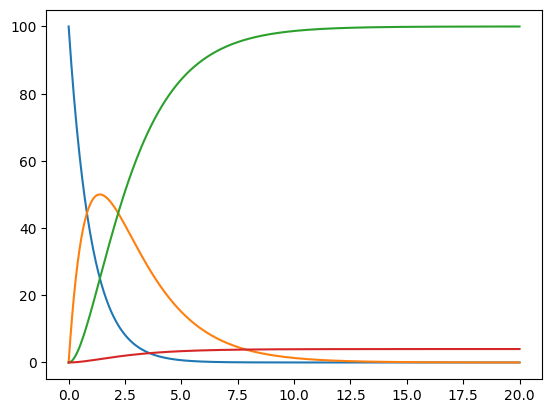

In [23]:
plt.plot(solution.t, solution.y.T)